# Imports

In [1]:
import pandas as pd
from qqman import qqman
import matplotlib.pyplot as plt
import numpy as np

# Plink vs. Python

## Plink GWAS Manhattan and QQ Plot

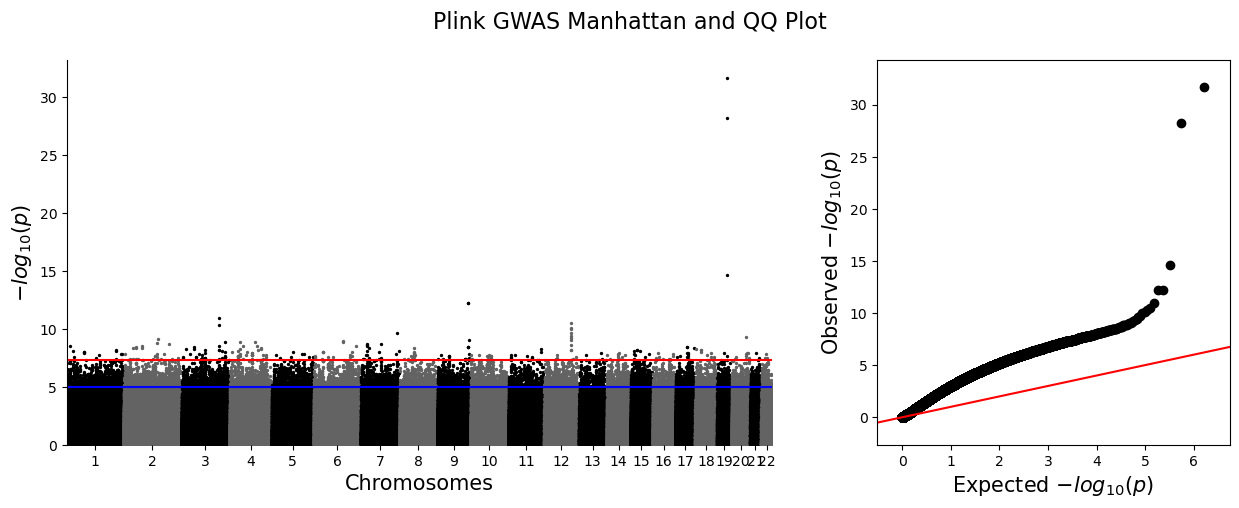

In [2]:
plink = pd.read_csv("data/ps3_gwas.assoc.linear", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("Plink GWAS Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(plink, ax=ax0)
qqman.qqplot(plink, ax=ax1)

## GWAS in Python Manhattan and QQ Plot

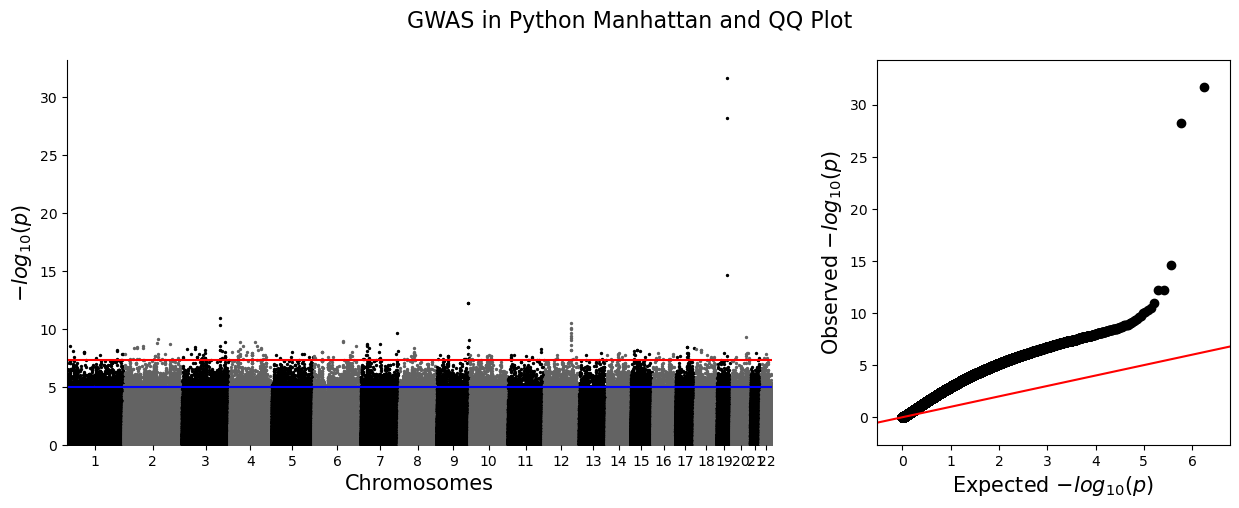

In [3]:
gwas_py = pd.read_csv("gwas_results.tsv", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("GWAS in Python Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(gwas_py, ax=ax0)
qqman.qqplot(gwas_py, ax=ax1)

## Effect Size Comparison

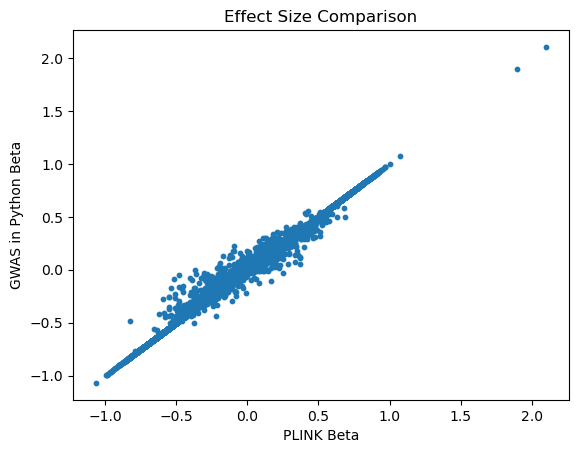

In [4]:
merged = plink.merge(gwas_py, on="SNP", suffixes=("_plink", "_gwas_py"))
merged[["BETA_plink", "BETA_gwas_py"]].corr()

plt.scatter(merged["BETA_plink"], merged["BETA_gwas_py"], s=10)
plt.xlabel("PLINK Beta")
plt.ylabel("GWAS in Python Beta")
plt.title("Effect Size Comparison")
plt.show()

## P-Value Comparison

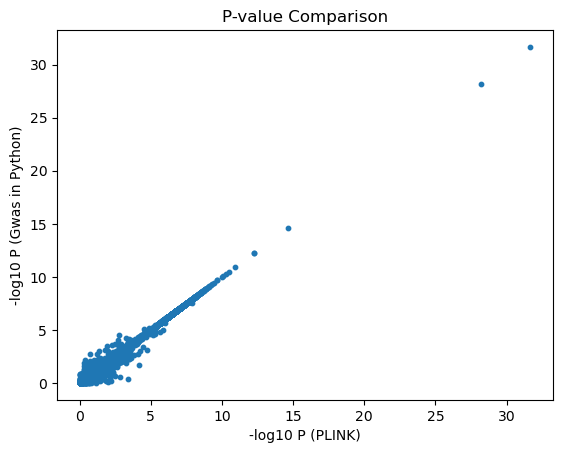

In [5]:
merged["logP_plink"] = -np.log10(merged["P_plink"])
merged["logP_gwas_py"]  = -np.log10(merged["P_gwas_py"])

plt.scatter(merged["logP_plink"], merged["logP_gwas_py"], s=10)
plt.xlabel("-log10 P (PLINK)")
plt.ylabel("-log10 P (Gwas in Python)")
plt.title("P-value Comparison")
plt.show()

In [6]:
merged["rank_plink"] = merged["P_plink"].rank(method="min")
merged["rank_gwas_py"]  = merged["P_gwas_py"].rank(method="min")

merged[["rank_plink", "rank_gwas_py"]].corr()

top_plink = set(plink.nsmallest(10, "P")["SNP"])
top_gwas_py  = set(gwas_py.nsmallest(10, "P")["SNP"])

print("Overlap in Top 10:", len(top_plink & top_gwas_py))

Overlap in Top 10: 10


In [7]:
summary = merged[[
    "SNP",
    "BETA_plink", "BETA_gwas_py",
    "P_plink", "P_gwas_py",
    "rank_plink", "rank_gwas_py"
]].sort_values("rank_plink").head(20)

summary

,SNP,BETA_plink,BETA_gwas_py,P_plink,P_gwas_py,rank_plink,rank_gwas_py
302264,rs62117204,2.1050,2.104528,2.122000e-32,2.121923e-32,1.0,1.0
302267,rs4803750,1.8980,1.898317,6.102000e-29,6.102444e-29,2.0,2.0
302263,rs1531517,1.0010,1.000888,2.328000e-15,2.327750e-15,3.0,3.0
833755,rs507666,-0.9908,-0.990820,5.676000e-13,5.675715e-13,4.0,4.0
833753,rs2519093,-0.9908,-0.990820,5.676000e-13,5.675715e-13,4.0,4.0
537174,rs358702,-0.5654,-0.565360,1.204000e-11,1.204200e-11,6.0,6.0
120646,rs11113551,-0.7108,-0.710799,3.291000e-11,3.290831e-11,7.0,7.0
537181,rs7636224,-0.5419,-0.541872,4.915000e-11,4.915194e-11,8.0,8.0
120635,rs2374725,-0.7102,-0.710158,8.035000e-11,8.035379e-11,9.0,9.0
120637,rs11113515,-0.6867,-0.686743,1.027000e-10,1.027314e-10,10.0,10.0


In [8]:
print("Beta correlation:", merged["BETA_plink"].corr(merged["BETA_gwas_py"]))

Beta correlation: 0.9999001853082442


# Plink vs. Python w/Covariance

## Plink GWAS Manhattan and QQ Plot

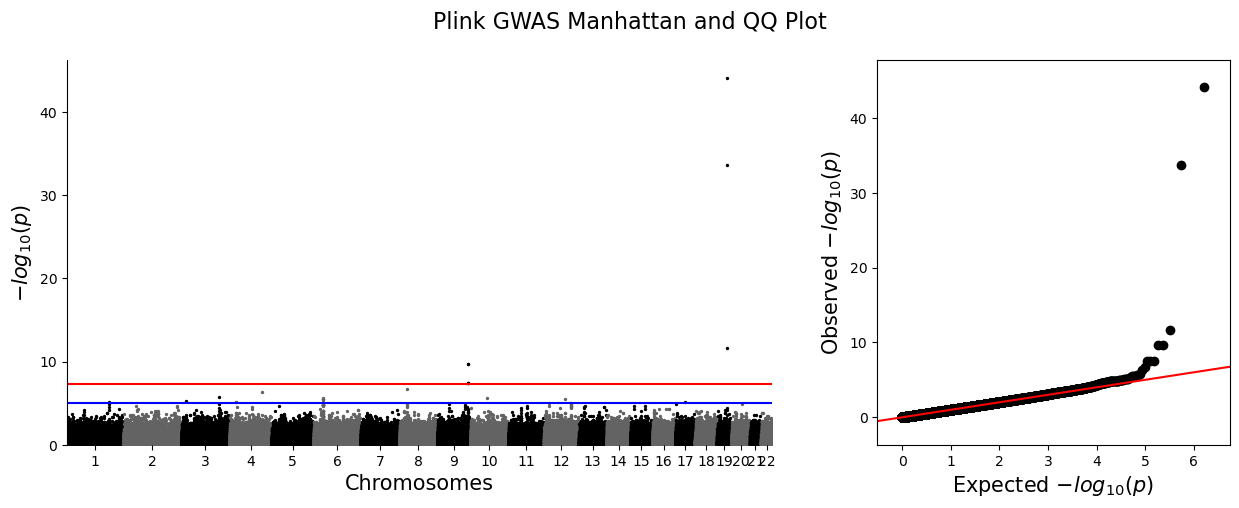

In [9]:
plink = pd.read_csv("data/ps3_gwas_covar.assoc.linear", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("Plink GWAS Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(plink, ax=ax0)
qqman.qqplot(plink, ax=ax1)

## GWAS in Python Manhattan and QQ Plot

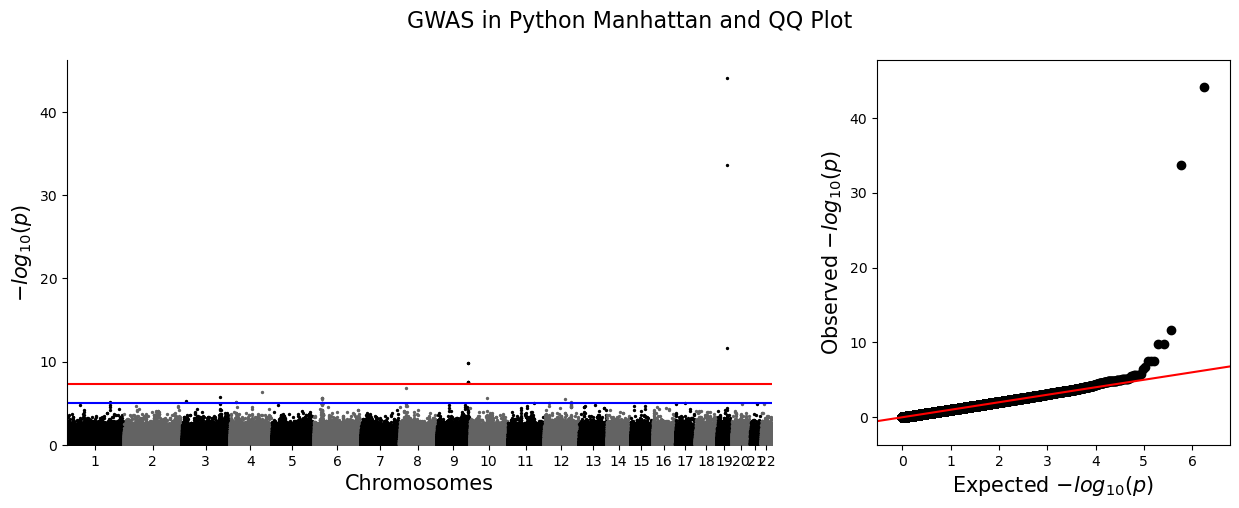

In [10]:
gwas_py = pd.read_csv("gwas_results_covar.tsv", sep=r"\s+")
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("GWAS in Python Manhattan and QQ Plot", fontsize=16)
qqman.manhattan(gwas_py, ax=ax0)
qqman.qqplot(gwas_py, ax=ax1)

## Effect Size Comparison

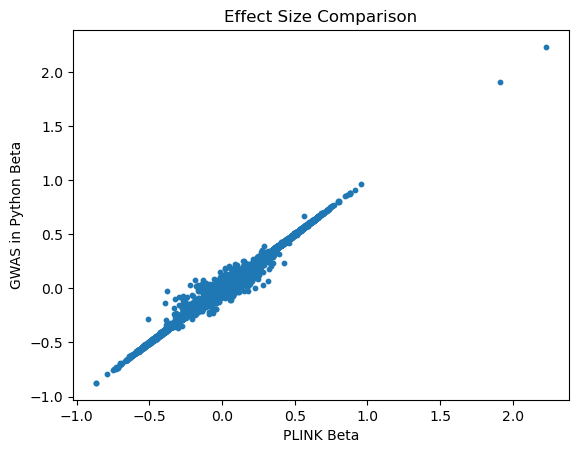

In [11]:
merged = plink.merge(gwas_py, on="SNP", suffixes=("_plink", "_gwas_py"))
merged[["BETA_plink", "BETA_gwas_py"]].corr()

plt.scatter(merged["BETA_plink"], merged["BETA_gwas_py"], s=10)
plt.xlabel("PLINK Beta")
plt.ylabel("GWAS in Python Beta")
plt.title("Effect Size Comparison")
plt.show()

## P-Value Comparison

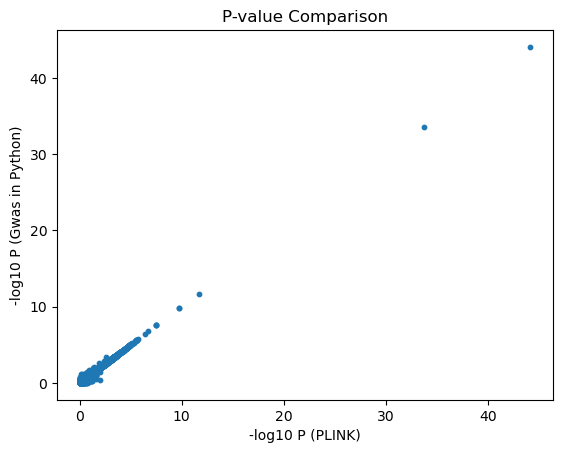

In [12]:
merged["logP_plink"] = -np.log10(merged["P_plink"])
merged["logP_gwas_py"]  = -np.log10(merged["P_gwas_py"])

plt.scatter(merged["logP_plink"], merged["logP_gwas_py"], s=10)
plt.xlabel("-log10 P (PLINK)")
plt.ylabel("-log10 P (Gwas in Python)")
plt.title("P-value Comparison")
plt.show()

In [13]:
merged["rank_plink"] = merged["P_plink"].rank(method="min")
merged["rank_gwas_py"]  = merged["P_gwas_py"].rank(method="min")

merged[["rank_plink", "rank_gwas_py"]].corr()

top_plink = set(plink.nsmallest(10, "P")["SNP"])
top_gwas_py  = set(gwas_py.nsmallest(10, "P")["SNP"])

print("Overlap in Top 10:", len(top_plink & top_gwas_py))

Overlap in Top 10: 10


In [14]:
summary = merged[[
    "SNP",
    "BETA_plink", "BETA_gwas_py",
    "P_plink", "P_gwas_py",
    "rank_plink", "rank_gwas_py"
]].sort_values("rank_plink").head(20)

summary

,SNP,BETA_plink,BETA_gwas_py,P_plink,P_gwas_py,rank_plink,rank_gwas_py
302264,rs62117204,2.2320,2.232244,7.782000e-45,8.170536e-45,1.0,1.0
302267,rs4803750,1.9110,1.910680,2.122000e-34,2.294679e-34,2.0,2.0
302263,rs1531517,0.8782,0.878578,2.279000e-12,2.256419e-12,3.0,3.0
833755,rs507666,-0.8700,-0.873846,2.024000e-10,1.640214e-10,4.0,4.0
833753,rs2519093,-0.8700,-0.873846,2.024000e-10,1.640214e-10,4.0,4.0
833762,rs495828,-0.6946,-0.698511,3.333000e-08,2.730954e-08,6.0,6.0
833761,rs579459,-0.6946,-0.698511,3.333000e-08,2.730954e-08,6.0,6.0
833760,rs651007,-0.6946,-0.698511,3.333000e-08,2.730954e-08,6.0,6.0
759798,rs962040,0.6920,0.694285,1.900000e-07,1.736315e-07,9.0,9.0
588159,rs3804100,0.8599,0.861290,4.352000e-07,4.194258e-07,10.0,10.0


In [15]:
print("Beta correlation:", merged["BETA_plink"].corr(merged["BETA_gwas_py"]))

Beta correlation: 0.9996943531012759
